Optimal K value:34
Accuracy:0.64

Classification report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.69      0.75      0.72        96
           6       0.58      0.70      0.64        99
           7       0.71      0.19      0.30        26
           8       0.00      0.00      0.00         2

    accuracy                           0.64       229
   macro avg       0.40      0.33      0.33       229
weighted avg       0.62      0.64      0.61       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


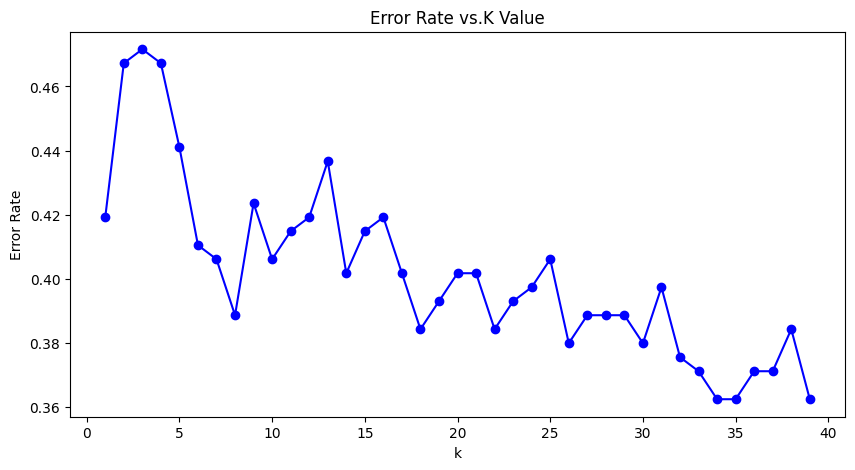

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
df=pd.read_csv('WineQT.csv')
X=df.drop(['quality','Id'],axis=1)
y=df['quality']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
error_rates=[]
for k in range(1,40):
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train,y_train)
  pred=knn.predict(X_test)
  error_rates.append(1-accuracy_score(y_test,pred))
best_k=error_rates.index(min(error_rates))+1
print(f"Optimal K value:{best_k}")
knn_final=KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train,y_train)
y_pred=knn_final.predict(X_test)
print(f"Accuracy:{accuracy_score(y_test,y_pred):.2f}")
print("\nClassification report:\n",classification_report(y_test,y_pred))
plt.figure(figsize=(10,5))
plt.plot(range(1,40),error_rates,color='blue',marker='o')
plt.title('Error Rate vs.K Value')
plt.xlabel("k")
plt.ylabel('Error Rate')
plt.show()